Envioronment Setup

In [ ]:
# ==========================================
# Dataset QA Pipeline
# Project Echo
# Sprint 1
# ==========================================

In [1]:
import sys
import platform
import importlib
from pathlib import Path
import zipfile

def package_version(package):
    try:
        return importlib.import_module(package).__version__
    except Exception:
        return "Not Installed"

print("="*60)
print("Dataset QA Pipeline Environment")
print("="*60)

print(f"Python Version: {sys.version.split()[0]}")
print(f"Platform: {platform.system()} {platform.release()}")

print()

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "librosa",
    "soundfile",
    "scipy",
    "tqdm"
]

for package in packages:
    print(f"{package.capitalize()} Version: {package_version(package)}")

Dataset QA Pipeline Environment
Python Version: 3.12.13
Platform: Linux 6.6.122+

Numpy Version: 2.0.2
Pandas Version: 2.2.2
Matplotlib Version: 3.10.0
Seaborn Version: 0.13.2
Librosa Version: 0.11.0
Soundfile Version: 0.14.0
Scipy Version: 1.16.3
Tqdm Version: 4.67.3


In [2]:
#run this for colab only
try:
    import google.colab

    IN_COLAB = True

except ImportError:

    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

if IN_COLAB:

    !pip -q install librosa soundfile seaborn tqdm

Running in Google Colab: True


Configuration

In [5]:
# ==========================================
# CONFIGURATION
# ==========================================

 #change accordingly
PROJECT_ROOT = Path.cwd()

ZIP_PATH = PROJECT_ROOT / "datasets.zip"

if not (PROJECT_ROOT / "datasets").exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(PROJECT_ROOT)

DATASET_PATH = PROJECT_ROOT / "datasets"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH}. "
        "Please place your dataset inside a folder named 'datasets'."
    )

SUPPORTED_AUDIO_EXTENSIONS = [
    ".wav",
    ".mp3",
    ".flac",
    ".ogg",
    ".m4a"
]

MIN_DURATION = 1.0

MAX_DURATION = 10.0

REPORT_OUTPUT = PROJECT_ROOT / "reports"

GENERATE_CSV = True

GENERATE_TEXT_REPORT = True

Imports

In [6]:
import os
import re
import json
import hashlib
import warnings

import librosa
import soundfile as sf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

Data set discovery and manifest builder

In [18]:
# ==========================================
# DATASET DISCOVERY
# ==========================================
class DatasetScanner:

    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)


    def scan_files(self):
        """
        Scan every file in dataset.
        """

        records = []

        for file in self.dataset_path.rglob("*"):

            if file.is_file():

                relative = file.relative_to(self.dataset_path)

                records.append({

                    "file_name": file.name,

                    "absolute_path": str(file),

                    "relative_path": str(relative).replace("\\","/"),

                    "extension": file.suffix.lower(),

                    "size_bytes": file.stat().st_size

                })


        return pd.DataFrame(records)

    def check_paths(self, df):

      """
    Check for inconsistent folder structures.
    Expected format:
        dataset/species/audio_file
    Also checks whether all files have a consistent folder depth.
    """

      depths = []
      status = []

      # Count folder depth for every file
      for path in df["relative_path"]:
        depths.append(len(Path(path).parts))

      # Most common folder depth
      expected_depth = max(set(depths), key=depths.count)

      # Validate each path
      for path, depth in zip(df["relative_path"], depths):
        parts = Path(path).parts

        if len(parts) < 2:
            status.append("Missing species folder")

        elif parts[0] == "":
            status.append("Invalid species folder")

        elif depth != expected_depth:
            status.append(f"Inconsistent depth ({depth} levels)")

        else:
            status.append("OK")
      df["path_status"] = status

      return df

    def detect_species(self, df):
        """
        Assumes first folder after dataset root is species label.
        """

        species=[]

        for path in df["relative_path"]:

            parts = Path(path).parts

            if len(parts)>1:
                species.append(parts[0])

            else:
                species.append("unknown")


        df["raw_species"]=species

        return df



scanner = DatasetScanner(DATASET_PATH)


manifest = scanner.scan_files()

manifest = scanner.detect_species(manifest)


print("Files found:",len(manifest))

manifest.head()

Files found: 46


,file_name,absolute_path,relative_path,extension,size_bytes,raw_species
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown
1,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown
2,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown
3,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown
4,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown


Structure validation

In [19]:
# ==========================================
# LABEL NORMALISATION
# ==========================================
def normalise_label(name):

    name=str(name).lower().strip()

    name=re.sub(
        r"[^a-z0-9]+",
        "_",
        name
    )

    name=re.sub(
        r"_+",
        "_",
        name
    )

    return name.strip("_")



manifest["species_label"] = (
    manifest["raw_species"]
    .apply(normalise_label)
)


manifest.head()

,file_name,absolute_path,relative_path,extension,size_bytes,raw_species,species_label
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown,unknown
1,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown,unknown
2,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown,unknown
3,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown,unknown
4,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown,unknown


In [20]:
# ==========================================
# STRUCTURE VALIDATION
# ==========================================
def validate_structure(df):

    results=[]


    # Empty files

    empty_files=df[
        df["size_bytes"]==0
    ]


    results.append({

        "check":
        "Empty files",

        "count":
        len(empty_files)

    })


    # Missing labels

    missing_labels=df[
        df["species_label"]
        .isin(["unknown",""])
    ]


    results.append({

        "check":
        "Missing species labels",

        "count":
        len(missing_labels)

    })


    # Unsupported files

    unsupported=df[
        ~df.extension.isin(
            SUPPORTED_AUDIO_EXTENSIONS
        )
    ]


    results.append({

        "check":
        "Unsupported extensions",

        "count":
        len(unsupported)

    })


    return pd.DataFrame(results)



structure_report = validate_structure(manifest)


structure_report

,check,count
0,Empty files,0
1,Missing species labels,5
2,Unsupported extensions,1


In [21]:
def validate_format(extension):

    if extension in SUPPORTED_AUDIO_EXTENSIONS:
        return "OK"

    else:
        return "unsupported_format"

manifest["format_status"] = (
    manifest["extension"]
    .apply(validate_format)
)

Audio quality validation

In [22]:
# ==========================================
# AUDIO VALIDATION
# ==========================================


def validate_audio(path):

    result={

        "readable":False,

        "duration":None,

        "sample_rate":None,

        "channels":None,

        "issue":""

    }


    try:

        audio,sr = librosa.load(
            path,
            sr=None,
            mono=False
        )


        result["readable"]=True

        result["sample_rate"]=sr


        if audio.ndim==1:
            channels=1

        else:
            channels=audio.shape[0]


        result["channels"]=channels


        duration=librosa.get_duration(
            y=audio,
            sr=sr
        )


        result["duration"]=round(
            duration,
            3
        )


        if duration < MIN_DURATION:

            result["issue"]="too_short"


        elif duration > MAX_DURATION:

            result["issue"]="too_long"


    except Exception as e:

        result["issue"]="unreadable"



    return result

In [23]:
# Run audio validation
audio_checks = (
    manifest["absolute_path"]
    .apply(validate_audio)
)

audio_checks = pd.DataFrame(audio_checks.tolist())

manifest = pd.concat(
    [manifest, audio_checks],
    axis=1
)

manifest.head()

/tmp/ipykernel_3287/2353648396.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio,sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3287/2353648396.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio,sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


,file_name,absolute_path,relative_path,extension,size_bytes,raw_species,species_label,format_status,readable,duration,sample_rate,channels,issue
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown,unknown,OK,True,8.813,44100.0,2.0,
1,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown,unknown,OK,True,12.564,44100.0,1.0,too_long
2,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown,unknown,OK,True,8.568,44100.0,2.0,
3,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown,unknown,OK,True,14.106,44100.0,2.0,too_long
4,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown,unknown,OK,True,24.465,44100.0,2.0,too_long


In [24]:
print(manifest)

                                            file_name  \
0   XC181330 - Red-browed Pardalote - Pardalotus r...   
1   XC36630 - Red-browed Pardalote - Pardalotus ru...   
2          XC350439 - Rose Robin - Petroica rosea.mp3   
3   XC143502 - Brown Gerygone - Gerygone mouki ric...   
4          XC550699 - Rose Robin - Petroica rosea.mp3   
5                            region_11.250-13.250.mp3   
6                          region_156.550-158.550.mp3   
7                            region_13.600-14.150.mp3   
8                              region_2.000-4.000.mp3   
9                            region_10.900-12.750.mp3   
10                             region_3.000-4.950.wav   
11                             Ground_Parrot (15).wav   
12                             Ground_Parrot (12).mp3   
13                             Ground_Parrot (15).mp3   
14                             region_5.200-7.200.mp3   
15                           region_29.200-31.200.wav   
16                           re

Data set statistics

In [25]:
# ==========================================
# DATASET STATISTICS
# ==========================================


species_counts = (
    manifest
    .groupby("species_label")
    .size()
    .reset_index(
        name="file_count"
    )
)


species_counts.sort_values(
    "file_count",
    ascending=False
)

,species_label,file_count
12,unknown,5
7,parvipsitta_pusilla,4
10,spilopelia_chinensis,4
2,branta_bernical_nigricans,3
0,acanthiza_reguloides,3
1,asio_flammeus,3
5,falco_cenchroides,3
4,ceyx_azureus,3
3,capra_hircus,3
6,lalage_leucomela,3


Report genration

In [26]:
REPORT_PATH = Path(REPORT_OUTPUT)

REPORT_PATH.mkdir(
    exist_ok=True
)

manifest.to_csv(
    REPORT_PATH /
    "dataset_manifest.csv",
    index=False
)


structure_report.to_csv(
    REPORT_PATH /
    "structure_report.csv",
    index=False
)


species_counts.to_csv(
    REPORT_PATH /
    "species_counts.csv",
    index=False
)

In [27]:
def generate_summary():

    summary={

        "total_files":
        len(manifest),


        "species_count":
        manifest.species_label.nunique(),


        "unreadable_audio":
        sum(
            manifest.issue=="unreadable"
        ),


        "missing_labels":
        sum(
            manifest.species_label=="unknown"
        ),


        "empty_files":
        sum(
            manifest.size_bytes==0
        )

    }


    return pd.DataFrame(
        [summary]
    )


summary_report=generate_summary()


summary_report

,total_files,species_count,unreadable_audio,missing_labels,empty_files
0,46,14,2,5,0


In [28]:
#add this analysis too as a addition - acoustic complexity with mutli labels
def analyse_acoustic_complexity(
    file_path,
    sample_rate=16000
):
    """
    Analyse environmental audio complexity.
    Only generates quality indicators.
    """

    result = {
        "file_path": file_path,
        "silence_ratio": None,
        "mean_energy": None,
        "energy_variance": None,
        "spectral_centroid": None,
        "quality_flag": None
    }


    try:

        audio, sr = librosa.load(
            file_path,
            sr=sample_rate,
            mono=True
        )


        # RMS energy
        rms = librosa.feature.rms(
            y=audio
        )[0]


        silence_ratio = np.mean(
            rms < 0.01
        )


        mean_energy = np.mean(rms)

        energy_variance = np.var(rms)


        spectral_centroid = np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sample_rate
            )
        )


        # Quality rules
        if silence_ratio > 0.8:

            flag = "HIGH_SILENCE"


        elif mean_energy < 0.01:

            flag = "LOW_SIGNAL"


        elif energy_variance > 0.05:

            flag = "HIGH_VARIABILITY"


        else:

            flag = "GOOD"


        result.update({

            "silence_ratio":
                round(float(silence_ratio),4),

            "mean_energy":
                round(float(mean_energy),6),

            "energy_variance":
                round(float(energy_variance),6),

            "spectral_centroid":
                round(float(spectral_centroid),3),

            "quality_flag":
                flag
        })


    except Exception as e:

        result["quality_flag"] = "ERROR"
        result["error"] = str(e)


    return result

/tmp/ipykernel_3287/1959358747.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_3287/1959358747.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


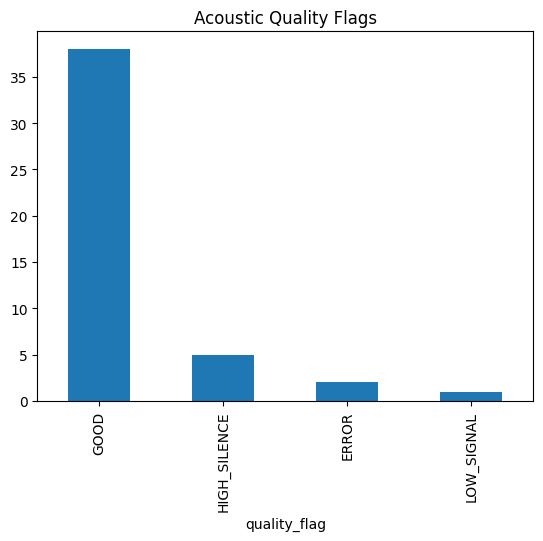

In [29]:
acoustic_results = []


for _, row in manifest.iterrows():

    result = analyse_acoustic_complexity(
        row["absolute_path"]
    )

    result["species"] = row["species_label"]

    acoustic_results.append(result)


acoustic_report = pd.DataFrame(
    acoustic_results
)

acoustic_report.head()

acoustic_report["quality_flag"].value_counts().plot(
    kind="bar",
    title="Acoustic Quality Flags"
)

plt.show()

In [31]:
print(acoustic_report)

                                            file_path  silence_ratio  \
0   /content/datasets/XC181330 - Red-browed Pardal...         0.1884   
1   /content/datasets/XC36630 - Red-browed Pardalo...         0.1679   
2   /content/datasets/XC350439 - Rose Robin - Petr...         1.0000   
3   /content/datasets/XC143502 - Brown Gerygone - ...         0.1995   
4   /content/datasets/XC550699 - Rose Robin - Petr...         0.0353   
5   /content/datasets/Acanthiza reguloides/region_...         0.0923   
6   /content/datasets/Acanthiza reguloides/region_...         0.1719   
7   /content/datasets/Acanthiza reguloides/region_...         0.8421   
8   /content/datasets/Falco cenchroides/region_2.0...         0.0000   
9   /content/datasets/Falco cenchroides/region_10....         0.1186   
10  /content/datasets/Falco cenchroides/region_3.0...         0.1613   
11  /content/datasets/Pezoporus wallicus/Ground_Pa...         0.3810   
12  /content/datasets/Pezoporus wallicus/Ground_Pa...         0.

DataSet QA Pipeline runner class



In [ ]:
# ==========================================
# CONFIGURATION
# ==========================================

from pathlib import Path
import zipfile


PROJECT_ROOT = Path.cwd()

ZIP_PATH = PROJECT_ROOT / "datasets.zip"

DATASET_FOLDER = PROJECT_ROOT / "datasets"

REPORT_OUTPUT = PROJECT_ROOT / "reports"


SUPPORTED_AUDIO_EXTENSIONS = [
    ".wav",
    ".mp3",
    ".flac",
    ".ogg",
    ".m4a"
]


MIN_DURATION = 1.0

MAX_DURATION = 10.0


# Acoustic feature extraction resolution
# Original sample rates are preserved in the manifest
ACOUSTIC_SAMPLE_RATE = 16000



# ==========================================
# DATASET SETUP
# ==========================================

def prepare_dataset():

    """
    Extract dataset zip if dataset folder does not exist.
    """

    if not DATASET_FOLDER.exists():

        if not ZIP_PATH.exists():

            raise FileNotFoundError(
                f"No dataset folder or zip found.\n"
                f"Expected: {ZIP_PATH}"
            )


        print("Extracting dataset...")

        with zipfile.ZipFile(
            ZIP_PATH,
            "r"
        ) as zip_ref:

            zip_ref.extractall(
                PROJECT_ROOT
            )


    if not DATASET_FOLDER.exists():

        raise FileNotFoundError(
            f"Dataset folder not found: {DATASET_FOLDER}"
        )


    return DATASET_FOLDER



# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":


    print("=" * 60)

    print(
        "Dataset QA Pipeline Started"
    )

    print("=" * 60)


    dataset_path = prepare_dataset()


    pipeline = DatasetQAPipeline(
        dataset_path=dataset_path,
        report_path=REPORT_OUTPUT
    )


    manifest = pipeline.run()


    print()

    print(
        f"Completed successfully."
    )

    print(
        f"Files analysed: {len(manifest)}"
    )

    print(
        f"Reports saved to: {REPORT_OUTPUT}"
    )

    print("=" * 60)

In [ ]:
# ==========================================
# DATASET QA PIPELINE CONTROLLER - can be used as .py file
# ==========================================


class DatasetQAPipeline:


    def __init__(
        self,
        dataset_path,
        report_path="reports"
    ):

        self.dataset_path = Path(dataset_path)

        self.report_path = Path(report_path)

        self.report_path.mkdir(
            exist_ok=True
        )


        self.manifest = None

        self.reports = {}

        self.acoustic_report = None



    # --------------------------------------
    # Step 1: Dataset discovery
    # --------------------------------------

    def discover(self):

        print(
            "Scanning dataset..."
        )


        scanner = DatasetScanner(
            self.dataset_path
        )


        self.manifest = scanner.scan_files()


        # Path structure check

        self.manifest = scanner.check_paths(
            self.manifest
        )


        # Extract species folder names

        self.manifest = scanner.detect_species(
            self.manifest
        )


        # Normalise labels

        self.manifest["species_label"] = (
            self.manifest["raw_species"]
            .apply(normalise_label)
        )


        # Validate extensions

        self.manifest["format_status"] = (
            self.manifest["extension"]
            .apply(validate_format)
        )


        print(
            f"Files discovered: {len(self.manifest)}"
        )



    # --------------------------------------
    # Step 2: Structure validation
    # --------------------------------------

    def validate_structure_report(self):

        print(
            "Running structure validation..."
        )


        structure_report = validate_structure(
            self.manifest
        )


        self.reports[
            "structure_report"
        ] = structure_report



    # --------------------------------------
    # Step 3: Audio validation
    # --------------------------------------

    def validate_audio_files(self):

        print(
            "Running audio validation..."
        )


        audio_results = []


        for _, row in tqdm(
            self.manifest.iterrows(),
            total=len(self.manifest)
        ):


            result = validate_audio(
                row["absolute_path"]
            )


            audio_results.append(
                result
            )


        audio_df = pd.DataFrame(
            audio_results
        )


        self.manifest = pd.concat(
            [
                self.manifest.reset_index(drop=True),
                audio_df.reset_index(drop=True)
            ],
            axis=1
        )



    # --------------------------------------
    # Step 4: Acoustic complexity analysis
    # --------------------------------------

    def run_acoustic_analysis(self):

        print(
            "Running acoustic complexity analysis..."
        )


        acoustic_results = []


        for _, row in tqdm(
            self.manifest.iterrows(),
            total=len(self.manifest)
        ):


            result = analyse_acoustic_complexity(
                row["absolute_path"]
            )


            result["species"] = (
                row["species_label"]
            )


            acoustic_results.append(
                result
            )


        self.acoustic_report = pd.DataFrame(
            acoustic_results
        )



    # --------------------------------------
    # Step 5: Generate reports
    # --------------------------------------

    def generate_reports(self):

        print(
            "Generating reports..."
        )


        # -------------------------------
        # Species counts
        # -------------------------------

        species_counts = (

            self.manifest

            .groupby(
                "species_label"
            )

            .size()

            .reset_index(
                name="file_count"
            )

            .sort_values(
                "file_count",
                ascending=False
            )

        )


        self.reports[
            "species_counts"
        ] = species_counts



        # -------------------------------
        # Dataset summary
        # -------------------------------

        summary = {


            "total_files":

            len(self.manifest),



            "species_count":

            self.manifest[
                "species_label"
            ].nunique(),



            "unreadable_audio":

            (
                self.manifest["issue"]
                ==
                "unreadable"
            ).sum(),



            "missing_labels":

            (
                self.manifest["species_label"]
                ==
                "unknown"
            ).sum(),



            "inconsistent_paths":

            (
                self.manifest["path_status"]
                !=
                "OK"
            ).sum(),



            "empty_files":

            (
                self.manifest["size_bytes"]
                ==
                0
            ).sum(),



            "duration_issues":

            (
                self.manifest["issue"]
                .isin(
                    [
                        "too_short",
                        "too_long"
                    ]
                )
            ).sum(),



            "unsupported_formats":

            (
                self.manifest["format_status"]
                ==
                "unsupported_format"
            ).sum()

        }


        self.reports[
            "dataset_summary"
        ] = pd.DataFrame(
            [summary]
        )



    # --------------------------------------
    # Step 6: Export reports
    # --------------------------------------

    def export_reports(self):

        print(
            "Saving reports..."
        )


        # Main manifest

        self.manifest.to_csv(
            self.report_path /
            "dataset_manifest.csv",
            index=False
        )


        # CSV reports

        for name, report in self.reports.items():


            report.to_csv(
                self.report_path /
                f"{name}.csv",
                index=False
            )



        # Acoustic report

        if self.acoustic_report is not None:


            self.acoustic_report.to_csv(
                self.report_path /
                "acoustic_complexity_report.csv",
                index=False
            )


        print(
            "Reports saved."
        )



    # --------------------------------------
    # Full pipeline execution
    # --------------------------------------

    def run(self):

        print("=" * 50)

        print(
            "Dataset QA Pipeline Started"
        )

        print("=" * 50)



        self.discover()


        self.validate_structure_report()


        self.validate_audio_files()


        self.run_acoustic_analysis()


        self.generate_reports()


        self.export_reports()



        print("=" * 50)

        print(
            "Dataset QA Pipeline Completed"
        )

        print("=" * 50)


        return self.manifest

In [ ]:
#Sprint 1
#Raveesha Somawansa
#s225559348